# PYTHON CAPSTONE PROJECT:
- "California's Emergency Department Volume & Capacity for years (2021 to 2023)

## A. UPLOADING FILE:
- The .csv file is downloaded from dataset source and save it on hard-disk.
- Uploaded the .csv file into my "GITHUB REPOSITORY".
- Raw link is obtained as URL for .csv & is assigned into our new panda's dataframe (df).

In [1]:
import pandas as pd

URL = "https://raw.githubusercontent.com/tseringdorjee15/DATA_ANALYTICS/refs/heads/main/emergency_department_volume_and_capacity_2021_to_2023.csv"
df = pd.read_csv(URL)

print(df.shape)               # returns (# of rows, # of columns)

print(df.index)               # prints row labels (index) of a DataFrame. how rows are labeled (which "column" acts as the index)3

print(df.dtypes)              # Displays the data types (dtype) of every column in a DataFrame

df.describe()


(12849, 18)
RangeIndex(start=0, stop=12849, step=1)
oshpd_id                      int64
FacilityName2                object
CountyName                   object
system                       object
year                          int64
LICENSED_BED_SIZE            object
HospitalOwnership            object
UrbanRuralDesi               object
TEACHINGDesignation          object
Category                     object
Tot_ED_NmbVsts                int64
EDStations                  float64
EDDXCount                     int64
LATITUDE                    float64
LONGITUDE                   float64
PrimaryCareShortageArea      object
MentalHealthShortageArea     object
Visits_Per_Station          float64
dtype: object


,oshpd_id,year,Tot_ED_NmbVsts,EDStations,EDDXCount,LATITUDE,LONGITUDE,Visits_Per_Station
count,1.284900e+04,12849.000000,12849.000000,12832.000000,12849.000000,12849.000000,12849.000000,12832.000000
mean,1.062833e+08,2022.006226,39642.067632,28.596088,3756.252004,35.987183,-119.749849,138.749681
std,1.387678e+05,0.812108,26917.290211,20.756854,11414.191936,2.241393,2.055228,376.131473
min,1.060107e+08,2021.000000,511.000000,1.000000,0.000000,32.619090,-124.195140,0.000000
25%,1.061904e+08,2021.000000,18962.000000,12.000000,93.000000,34.026260,-121.802690,5.111111
50%,1.063012e+08,2022.000000,33711.000000,24.000000,513.000000,35.372801,-119.263110,22.869318
75%,1.063809e+08,2023.000000,54542.000000,40.000000,2133.000000,37.821060,-118.049255,84.265873
max,1.065810e+08,2023.000000,146799.000000,114.000000,146799.000000,41.773659,-114.595600,4714.000000


## B. SETTING AN INDEX
- Try to figure out which columns can be considered as an 'INDEX'

In [2]:
print(df.index)    #We found out that by-default INDEX for the dataset is integer numbers(starts=0, stop=12849, step-1)

print()

print(df['oshpd_id'].is_unique)
print()

if df['oshpd_id'].is_unique:
    print("oshpd_id is unique!")
else:                # if False
    print("oshpd_id is not unique")



RangeIndex(start=0, stop=12849, step=1)

False

oshpd_id is not unique


### - Setting 'Multi-Index
- Found our index 'oshpd_id' values are not unique & 12552 duplicate values are detected, We can suspect that dataset tracks data for 2021, 2022, and 2023, so one hospital has three separate rows.
- "MultiIndex" is performed to keep all data but identifies each row by the 'oshpd_id'+ 'year' column combination.

- "Reindex" is performed so that we can perform 'Cleaning' & 'further Analysis'
   by putting 'oshpd_id' & 'year' multi-indexed back to columns

In [3]:
df = df.reset_index()                                    # reset index which put "oshpd_id" an index made earlier will be sent back to columns lists

df.set_index(["oshpd_id", "year"], inplace=True)         # PERFORM 'MULTI-INDEX' on "oshpd_id" & "year" combined

if df.index.is_unique:                                   # check if 'MULTI-INDEX' is unique or not
    print("oshpd_id and year combination is unique!")
else:                                                    # Else, print saying "combination has duplicates"
    print("oshpd_id and year combination has duplicates")

""" Since both SINGLE-INDEX on ("oshpd_id") & MULTI-INDEX on ("oshpd_id", "year") are not unique,
    We will reset index to default, which is int number
"""
df = df.reset_index()


oshpd_id and year combination has duplicates


## C. CLEANING DATA

### 1. Initial Assessment (DATA EXPLORATION)
-Before changing anything, we will run following commands to find "the dirt":

  * **df.info():** Shows data types and how many non-null values are in each column.
  * **df.isnull()**.sum(): Gives a quick count of "how many values are missing per column."
  * **df.describe()**: generates a statistical summary of all numerical columns(count, mean, std (standard deviation), min, max, and the 25th, 50th (median), and 75th percentiles)
  * Heatmap is used to find Nan(missing values) using seaborn library

In [4]:
print(df.isnull().sum())

oshpd_id                       0
year                           0
index                          0
FacilityName2                  0
CountyName                     0
system                      3590
LICENSED_BED_SIZE              0
HospitalOwnership              0
UrbanRuralDesi                 0
TEACHINGDesignation            0
Category                       0
Tot_ED_NmbVsts                 0
EDStations                    17
EDDXCount                      0
LATITUDE                       0
LONGITUDE                      0
PrimaryCareShortageArea        0
MentalHealthShortageArea       0
Visits_Per_Station            17
dtype: int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12849 entries, 0 to 12848
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   oshpd_id                  12849 non-null  int64  
 1   year                      12849 non-null  int64  
 2   index                     12849 non-null  int64  
 3   FacilityName2             12849 non-null  object 
 4   CountyName                12849 non-null  object 
 5   system                    9259 non-null   object 
 6   LICENSED_BED_SIZE         12849 non-null  object 
 7   HospitalOwnership         12849 non-null  object 
 8   UrbanRuralDesi            12849 non-null  object 
 9   TEACHINGDesignation       12849 non-null  object 
 10  Category                  12849 non-null  object 
 11  Tot_ED_NmbVsts            12849 non-null  int64  
 12  EDStations                12832 non-null  float64
 13  EDDXCount                 12849 non-null  int64  
 14  LATITU

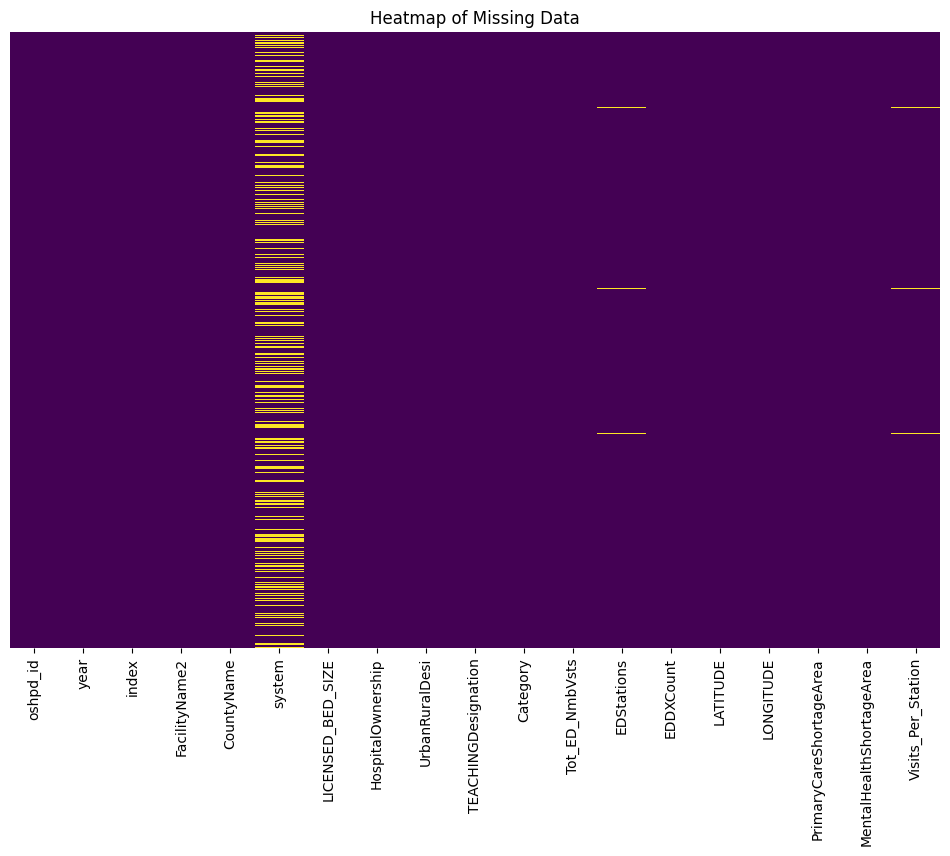

In [5]:
print(df.info())
print()

print(df.describe())
print(df.isnull().sum())
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap of missing values
# True (yellow/light) represents missing values; False (purple/dark) means data is present
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title('Heatmap of Missing Data')
plt.show()

###2. Standardize Text & Columns :
- Creating a uniform format for our data to ensure consistency, improve readability, and prevent errors during analysis

Healthcare datasets often have messy column names or inconsistent casing.

  * **Clean Column Names:** Since, we found inconsistencies in column names {eg: some are capitalized, some in lowercase etc). We will standardize by following *'SNAKE_CASE'*naming convention where all letters are converted into lowercase and multiple words are joined by underscores (_).


> Add blockquote


  **NOTE:**
  - It is the standard style recommended to improve code readability.

#### - Column names converted into 'lowercase'

In [6]:
df.columns = df.columns.str.lower()     # converts column names to 'lowercase'

print(df.columns)                       # checking if column names to converted to 'lowercase'

Index(['oshpd_id', 'year', 'index', 'facilityname2', 'countyname', 'system',
       'licensed_bed_size', 'hospitalownership', 'urbanruraldesi',
       'teachingdesignation', 'category', 'tot_ed_nmbvsts', 'edstations',
       'eddxcount', 'latitude', 'longitude', 'primarycareshortagearea',
       'mentalhealthshortagearea', 'visits_per_station'],
      dtype='object')


#### - Convert column names with multi-words into separate words by using underscore (_) in between

In [7]:
df = df.rename(columns={
    'facilityname2': 'facility_name',
    'countyname': 'county_name',
    'hospitalownership': 'hospital_ownership',
    'urbanruraldesi': 'urban_rural_desi',
    'teachingdesignation': 'teaching_designation',
    'tot_ed_nmbvsts': 'tot_ed_nmb_visits',
    'edstations': 'ed_stations',
    'eddxcount': 'ed_dx_count',
    'primarycareshortagearea': 'primary_care_shortage_area',
    'mentalhealthshortagearea': 'mentalhealth_shortage_area',
    'year' : 'year'
})

print(df.columns)                       #   # checking if multi-words column names to separated by underscore (_)

Index(['oshpd_id', 'year', 'index', 'facility_name', 'county_name', 'system',
       'licensed_bed_size', 'hospital_ownership', 'urban_rural_desi',
       'teaching_designation', 'category', 'tot_ed_nmb_visits', 'ed_stations',
       'ed_dx_count', 'latitude', 'longitude', 'primary_care_shortage_area',
       'mentalhealth_shortage_area', 'visits_per_station'],
      dtype='object')


### 3. Handling Missing Values

In healthcare data, missing values can represent "zero" or simply a failure to report.

- **Drop empty rows:** Use df.dropna(subset=['column'], inplace=True) if a row is useless without a specific piece of data.
- **Fill with Zero/Median:** Use df.fillna(0, inplace=True) for count columns, or use the median for more stable estimates.

#### - *Drop* & Fill "missing" or empty(NaN) row with 'median' value for number columns and 'unknown' for object or text cols:

- To drop: df = df.dropna(subset=['column'], inplace=True)
  - I decided not to drop any rows, instead missing datas are filled with suitable values(median) for count columns for more stable estimates.

- To fill: df = df.fillna()
   - for count columns, use the median for more stable estimates.
   - for text/object columns, use "Unknown"





In [8]:
def clean_dataset(df):
    """
    Cleans the California ED dataset by filling missing numbers with the median
    and missing text with 'Unknown'.
    """
    # 1. Filling all missing or Nan numeric columns with the median (to avoid outlier skew)
    numeric_cols = df.select_dtypes(include=['number']).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    # 2. Filling all missing or NaN text/object columns with "Unknown"
    object_cols = df.select_dtypes(include=['object']).columns
    df[object_cols] = df[object_cols].fillna("Unknown")

    return df

# Usage
df = clean_dataset(df)

# Quick Verify
print("Missing values per column after cleaning:")
print()
print(df.isnull().sum())

Missing values per column after cleaning:

oshpd_id                      0
year                          0
index                         0
facility_name                 0
county_name                   0
system                        0
licensed_bed_size             0
hospital_ownership            0
urban_rural_desi              0
teaching_designation          0
category                      0
tot_ed_nmb_visits             0
ed_stations                   0
ed_dx_count                   0
latitude                      0
longitude                     0
primary_care_shortage_area    0
mentalhealth_shortage_area    0
visits_per_station            0
dtype: int64


## D. DATA ANALYSIS:
- 1. Which Top 10 California counties have the highest "ed_burden_ratio": ('tot_ed_nmb_visits'/ 'ed_stations') & to what extend does it reveals healthcare burden across counties?
               

In [9]:
# Before analysis, "ed_burden_ratio" is yet to be calculated & let's create a new column under the same name
import numpy as np
import pandas as pd
df['ed_burden_ratio'] = df['tot_ed_nmb_visits'] / df['ed_stations']      # calculate the ratio and assign it to new column named 'ed_burden_ratio'

print()

# let's verify if the new column is in the dataframe as a new column
print("ed_burden_ratio" in df.columns)

# 3. Verify it worked (Sort by highest burden and print only the top 5)
print(df[['facility_name', 'ed_burden_ratio']].sort_values(by='ed_burden_ratio', ascending=False).head(5))


True
                      facility_name  ed_burden_ratio
8032   St. Louise Regional Hospital           4714.0
5764   St. Louise Regional Hospital           4714.0
5007   St. Louise Regional Hospital           4714.0
1232   St. Louise Regional Hospital           4714.0
11057  St. Louise Regional Hospital           4714.0


In [10]:
#average_county_ed_burden = df.groupby("county_name")["ed_burden_ratio"].mean().sort_values(ascending=False)

import pandas as pd

# Group by "county" and calculate the mean of the 'ED Burden Ratio' column named: "burden" & assigned it to a new variable 'average_county_ed_burden'
average_county_ed_burden = df.groupby("county_name")["ed_burden_ratio"].mean().sort_values(ascending=False)
print()
# Display the results
print(f"Top 10 ED Burden Ratio by County (2021-2023):")
print()
print(average_county_ed_burden.head(10))



Top 10 ED Burden Ratio by County (2021-2023):

county_name
Merced         2383.385897
Monterey       2374.099675
Kings          2201.631907
Imperial       2169.925000
Santa Clara    2059.334401
Santa Cruz     2036.848958
Tehama         2020.833333
Madera         1975.759868
Lake           1952.166667
San Joaquin    1886.793792
Name: ed_burden_ratio, dtype: float64


In [11]:
print(df.columns.tolist())


['oshpd_id', 'year', 'index', 'facility_name', 'county_name', 'system', 'licensed_bed_size', 'hospital_ownership', 'urban_rural_desi', 'teaching_designation', 'category', 'tot_ed_nmb_visits', 'ed_stations', 'ed_dx_count', 'latitude', 'longitude', 'primary_care_shortage_area', 'mentalhealth_shortage_area', 'visits_per_station', 'ed_burden_ratio']


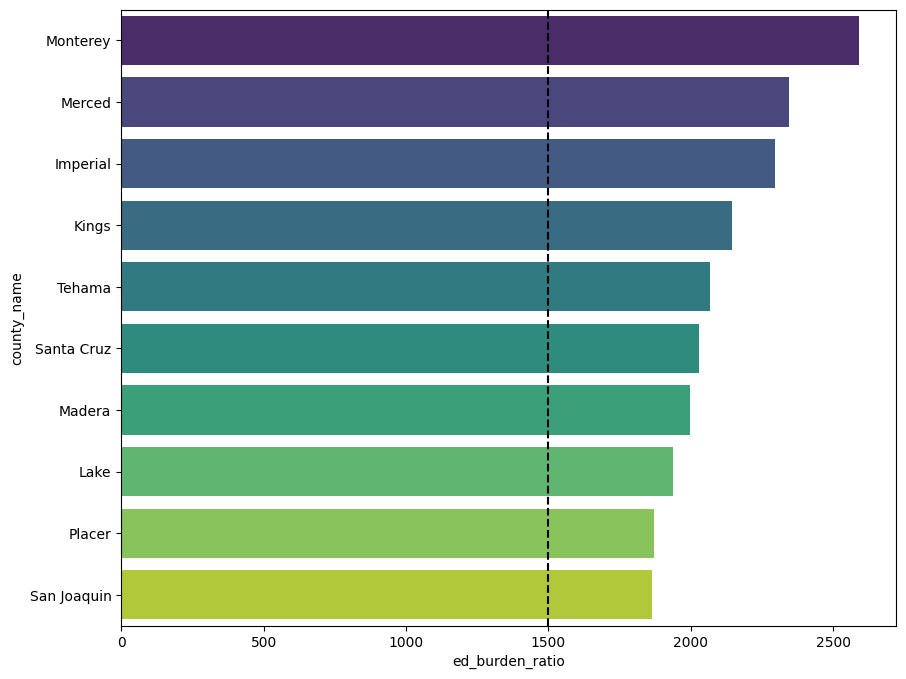

In [12]:
"""
---Targeting Hotspots: Any county bar that crosses that black line is officially operating above the statewide typical burden, which directly supports
    our problem statement about identifying "geographical hotspots."
---The Top 10 Gap: notice that top counties (like San Bernardino or Kern) don't just cross the line—they often dwarf it, highlighting where the "capacity crisis" is most extreme.

"""
import seaborn as sns

# 1. Prepare our data properly # since we have multi_indexed(oshpd_id, year), we to reset_index to make all columns instead of multi_indexed
df_plot = df.groupby('county_name')['ed_burden_ratio'].median().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 8))
sns.barplot(
    data=df_plot.head(10),     # Using .head(10) prevents the plot from being too crowded
    x='ed_burden_ratio',       # The column name for your values
    y='county_name',           # The column name for your labels
    hue='county_name',         # Colors the bars by county
    palette='viridis',         # Or your custom 'colors' list
    legend=False
)
plt.axvline(1500, color='black', linestyle='--', label='Critical Threshold (1,500)')
plt.show()

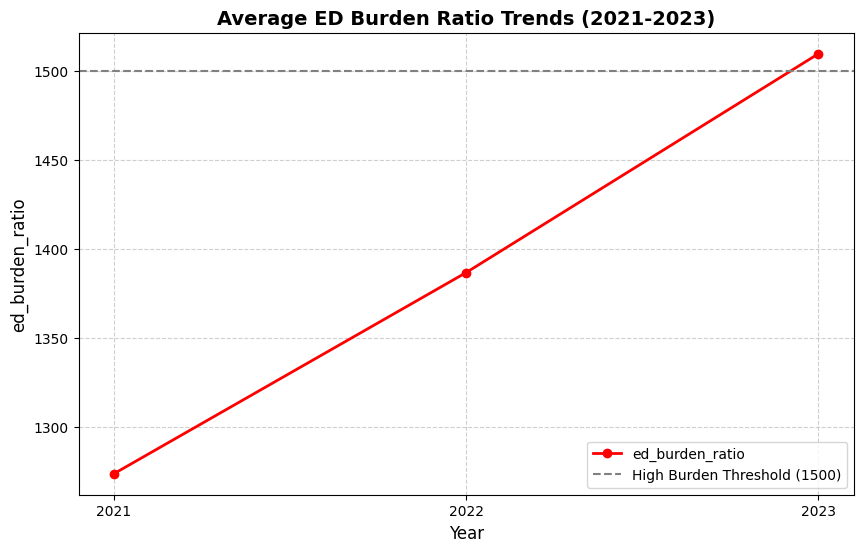

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Calculate the yearly average burden ratio
yearly_burden = df.groupby('year')['ed_burden_ratio'].median()  # new 'ed_burden_ratio' column already created earlier
                                                                # We can also calculate the average(median) of 'ed_burden_ratio' column grouped by year.
# 2. Setup the plot
plt.figure(figsize=(10, 6))
yearly_burden.plot(kind='line', marker='o', color='red', linewidth=2)

# 3. Force exact years and labels
target_years = [2021, 2022, 2023]
plt.xticks(target_years)

plt.title('Average ED Burden Ratio Trends (2021-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('ed_burden_ratio', fontsize=12)

# 4. Add the 1,500 Threshold Line
# This visually shows when the state average crosses into the "high strain" zone
plt.axhline(y=1500, color='gray', linestyle='--', label='High Burden Threshold (1500)')
plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [14]:
print(df.columns.tolist())

['oshpd_id', 'year', 'index', 'facility_name', 'county_name', 'system', 'licensed_bed_size', 'hospital_ownership', 'urban_rural_desi', 'teaching_designation', 'category', 'tot_ed_nmb_visits', 'ed_stations', 'ed_dx_count', 'latitude', 'longitude', 'primary_care_shortage_area', 'mentalhealth_shortage_area', 'visits_per_station', 'ed_burden_ratio']


## E. LINEAR REGRESSION
- To perform linear regression on the California ED burden data using Python, we can use the scikit-learn library. The median burden ratios from 2021 to 2023 is used to calculate the trend and forecast future years.
HCAI explicitly provides these median burden ratio values (2021:"1274", 2022: "1389.5", 2023: "1505" as part of its official benchmarking to help hospitals and analysts track emergency department (ED) overcrowding.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


2024 Forecasted Burden: 1620.50
2025 Forecasted Burden: 1736.00
Annual Growth Rate: 115.50 Burden Ratio/year


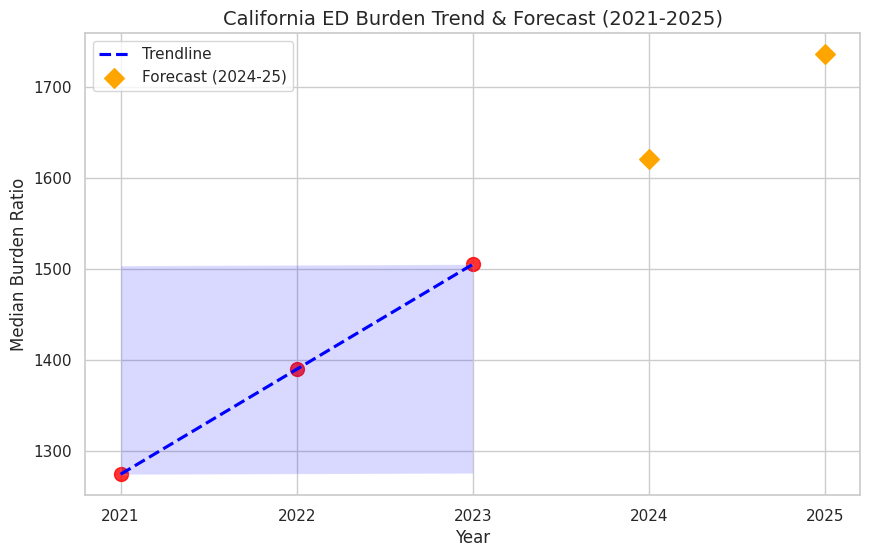

In [15]:
# PLOT TO SEE PREDICTION FOR YEARS : 2024 & 2025 using "SEABORN REGPLOT"

#  - visualizes the 2021–2023 California ED burden data, providing a clear visual guide to the rising trend.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

data = {
    'year': [2021, 2022, 2023],
    'burden': [1274, 1389.5, 1505]
}
df = pd.DataFrame(data)

# Perform Linear Regression for the Forecast
X = df[['year']]
y = df['burden']
model = LinearRegression().fit(X, y)

# Predict values for 2024 and 2025
future_years = np.array([[2024], [2025]])
future_preds = model.predict(future_years)

# Visualization with Seaborn
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Use regplot for historical data, trendline, and 95% confidence interval
sns.regplot(
    data=df,
    x='year',
    y='burden',
    ci=95,
    scatter_kws={'s': 100, 'color': 'red', 'label': 'Actual Data'},
    line_kws={'color': 'blue', 'linestyle': '--', 'label': 'Trendline'}
)

# Overlay the forecasted points as orange diamonds
plt.scatter([2024, 2025], future_preds, color='orange', marker='D', s=100, label='Forecast (2024-25)', zorder=5)

# 4. Final Formatting and Labels
plt.title('California ED Burden Trend & Forecast (2021-2025)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Median Burden Ratio', fontsize=12)
plt.xticks(np.arange(2021, 2026)) # Set x-axis to show each year clearly
plt.legend()

# Display results
print(f"2024 Forecasted Burden: {future_preds[0]:.2f}")
print(f"2025 Forecasted Burden: {future_preds[1]:.2f}")
print(f"Annual Growth Rate: {model.coef_[0]:.2f} Burden Ratio/year")

plt.show()
